# Blocking Evaluation on Synthetic Data

This notebook measures how well the **current production blocking strategy** recovers known matching record pairs, using a labeled synthetic dataset.

**It imports the live blocking code from `src/features/blocking.py` — nothing is copied.** Re-running this notebook after the blocking module changes will reflect those changes automatically.

## Data

- `data/synthetic/synthetic_blocking_testing.csv` — the **record pool** (20,000 unique records) that blocking is run over. One row per `PATID`. These are the deduplicated left/right records of the labeled pairs.
- `data/synthetic/synthetic_test_v2.csv` — the **ground truth**: candidate pairs with a `label` (1 = true match, 0 = hard negative), a `case_type` (the corruption scenario), and `entity_id_a`/`entity_id_b`.

## What we measure

Blocking is a **recall-first** filter: its job is to make sure true-match pairs survive into the candidate set so the downstream matcher can score them. So the headline metric is **pair completeness (recall)** — the share of true-match pairs that blocking emits as candidates. Precision is *not* a blocking concern (the matcher handles that), but we still report how much work blocking passes downstream.

1. **Pair completeness / recall** — overall and per-block, with marginal contribution.
2. **Recall by `case_type`** — which corruption scenarios blocking handles well vs. misses.
3. **Reduction ratio** — how aggressively blocking shrinks the all-pairs space.
4. **Hard-negative capture rate** — how many label-0 pairs blocking also surfaces (extra burden on the matcher).
5. **False-negative inspection** — the actual missed true pairs, for debugging.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Make the repo root importable so we use the LIVE blocking code ──────────
# This notebook lives in <repo>/notebooks/, so the repo root is one level up.
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "src" / "features" / "blocking.py").exists():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError("Could not locate repo root (src/features/blocking.py).")
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from src.features.blocking import run_batch_blocking, get_blocking_stats

print(f"Repo root: {REPO_ROOT}")
print("Imported run_batch_blocking, get_blocking_stats from src.features.blocking")

Repo root: /Users/miguelroca/Documents/UChicago/Capstone Project/EMPI
Imported run_batch_blocking, get_blocking_stats from src.features.blocking


## 1. Load the data

`dtype=str` is mandatory on the CSV reads — `PATID`, `SSN`, `ZipCD`, and `last_4_SSN` are digit strings with meaningful leading zeros (see the **Leading zeros invariant** in `CLAUDE.md`). Reading without it would silently strip zeros and corrupt both the keys and the recall measurement.

In [3]:
SYNTH_DIR = REPO_ROOT / "data" / "synthetic"
POOL_PATH  = SYNTH_DIR / "synthetic_blocking_testing.csv"
TRUTH_PATH = SYNTH_DIR / "synthetic_test_v3.csv"

# Record pool that blocking runs over (one row per PATID).
df_pool = pd.read_csv(POOL_PATH, dtype=str)

# Ground-truth labeled pairs.
df_truth = pd.read_csv(TRUTH_PATH, dtype=str)
df_truth["label"] = df_truth["label"].astype(int)

print(f"Record pool : {len(df_pool):,} rows | {df_pool['PATID'].nunique():,} unique PATIDs")
print(f"Truth pairs : {len(df_truth):,} rows")
print(df_truth['label'].value_counts().rename({1: 'match (label=1)', 0: 'non-match (label=0)'}))

Record pool : 20,000 rows | 20,000 unique PATIDs
Truth pairs : 10,000 rows
label
non-match (label=0)    8000
match (label=1)        2000
Name: count, dtype: int64


## 2. Build the ground-truth pair sets

We canonicalize every pair so `PATID_A < PATID_B`, matching the convention the blocking output uses. This lets us compare blocking's emitted pairs against the truth pairs as plain frozenset/tuple lookups.

- **`truth_positive`** — pairs with `label == 1`. These are the pairs blocking *must* recover. Recall is measured against this set.
- **`truth_negative`** — pairs with `label == 0` (hard negatives). Used only to report how many blocking also surfaces.

In [4]:
def _canon(a, b):
    """Canonical (lower, higher) PATID tuple — matches blocking's A<B output."""
    return (a, b) if a <= b else (b, a)

truth = df_truth.copy()
truth["pair"] = [ _canon(a, b) for a, b in zip(truth["PATID_A"], truth["PATID_B"]) ]

# A pair could in principle appear twice; keep one row per canonical pair.
truth = truth.drop_duplicates(subset="pair")

truth_pos = truth[truth["label"] == 1]
truth_neg = truth[truth["label"] == 0]

truth_pos_set = set(truth_pos["pair"])
truth_neg_set = set(truth_neg["pair"])

# Sanity check: every PATID referenced in the truth pairs must exist in the pool,
# otherwise blocking literally cannot recover it and recall would be unfairly low.
pool_ids = set(df_pool["PATID"])
truth_ids = set(truth["PATID_A"]) | set(truth["PATID_B"])
missing = truth_ids - pool_ids

print(f"True-match pairs (label=1) : {len(truth_pos_set):,}")
print(f"Hard-negative pairs (label=0): {len(truth_neg_set):,}")
print(f"PATIDs in truth missing from pool: {len(missing)}"
      + ("  ✓ all present" if not missing else "  ⚠ recall ceiling < 100%"))

True-match pairs (label=1) : 2,000
Hard-negative pairs (label=0): 8,000
PATIDs in truth missing from pool: 0  ✓ all present


## 3. Run the production blocking

We call `run_batch_blocking` exactly as the production pipeline does. It runs all 8 blocks (B1, B3–B9) and returns the deduplicated union of candidate pairs with `source_blocks` provenance.

The synthetic pool has no `valid_record` column, so the validity filter is fail-open — all 20,000 records are blocked.

In [5]:
candidate_pairs = run_batch_blocking(df_pool)

candidate_pairs["pair"] = [
    _canon(a, b) for a, b in zip(candidate_pairs["PATID_A"], candidate_pairs["PATID_B"])
]
candidate_set = set(candidate_pairs["pair"])

print(f"Blocking emitted {len(candidate_pairs):,} unique candidate pairs.")
candidate_pairs.head()

No 'valid_record' column found — proceeding without validity filter. All 20000 records will be blocked.


Blocking emitted 7,191 unique candidate pairs.


,PATID_A,PATID_B,source_blocks,n_blocks,pair
0,S000084695,S000084696,B1,1,"(S000084695, S000084696)"
1,S000080103,S000080104,B1|B3|B4|B5|B8|B9,6,"(S000080103, S000080104)"
2,S000085895,S000085896,B1,1,"(S000085895, S000085896)"
3,S000080125,S000080126,B1|B5,2,"(S000080125, S000080126)"
4,S000080053,S000080054,B1|B5,2,"(S000080053, S000080054)"


## 4. Headline metrics

**Pair completeness (recall)** is the single most important blocking metric:

$$\text{recall} = \frac{|\{\text{true-match pairs}\} \cap \{\text{candidate pairs}\}|}{|\{\text{true-match pairs}\}|}$$

**Reduction ratio** measures how much of the quadratic all-pairs space blocking eliminates:

$$\text{RR} = 1 - \frac{|\{\text{candidate pairs}\}|}{N(N-1)/2}$$

In [6]:
found_pos = truth_pos_set & candidate_set
missed_pos = truth_pos_set - candidate_set
recall = len(found_pos) / len(truth_pos_set) if truth_pos_set else float("nan")

found_neg = truth_neg_set & candidate_set
neg_capture = len(found_neg) / len(truth_neg_set) if truth_neg_set else float("nan")

N = df_pool["PATID"].nunique()
naive_pairs = N * (N - 1) // 2
reduction_ratio = 1 - len(candidate_set) / naive_pairs

print("================  BLOCKING EVALUATION  ================")
print(f"Records in pool (N)            : {N:,}")
print(f"Naive all-pairs  N(N-1)/2      : {naive_pairs:,}")
print(f"Candidate pairs emitted        : {len(candidate_set):,}")
print(f"Reduction ratio                : {reduction_ratio:.6f}  ({reduction_ratio*100:.4f}%)")
print("-" * 54)
print(f"True-match pairs (label=1)     : {len(truth_pos_set):,}")
print(f"  recovered by blocking        : {len(found_pos):,}")
print(f"  MISSED (false negatives)     : {len(missed_pos):,}")
print(f"  >>> PAIR COMPLETENESS (RECALL): {recall*100:.2f}%")
print("-" * 54)
print(f"Hard-negative pairs (label=0)  : {len(truth_neg_set):,}")
print(f"  also surfaced by blocking    : {len(found_neg):,}  ({neg_capture*100:.1f}%)")
print("  (these are passed to the matcher to reject — expected, not an error)")
print("======================================================")

================  BLOCKING EVALUATION  ================
Records in pool (N)            : 20,000
Naive all-pairs  N(N-1)/2      : 199,990,000
Candidate pairs emitted        : 7,191
Reduction ratio                : 0.999964  (99.9964%)
------------------------------------------------------
True-match pairs (label=1)     : 2,000
  recovered by blocking        : 1,942
  MISSED (false negatives)     : 58
  >>> PAIR COMPLETENESS (RECALL): 97.10%
------------------------------------------------------
Hard-negative pairs (label=0)  : 8,000
  also surfaced by blocking    : 1,123  (14.0%)
  (these are passed to the matcher to reject — expected, not an error)


## 4b. Stratified recall — recoverable vs. adversarial

The overall recall number lumps together two very different kinds of true-match pair:

- **Adversarial (`M-BULK-HARD`, `M-BULK-L4`)** — the generator corrupts nearly every identifying field at once (e.g. `replace_last` swaps the entire surname, plus `dob_drift`, `phone_replace`, `email_change`, `address_move`). These pairs share an `entity_id` so they are *defined* as the same patient, but on the visible fields they are indistinguishable from two different people — no deterministic block (and arguably no matcher) can bridge them. They are **unblockable by design**.
- **Recoverable (everything else)** — single- or light-multi-field corruptions (a name typo, a DOB shift, a phone change) where at least one block key should still survive. This is the recall that actually reflects how well the blocking scheme handles realistic data variation.

We report recall both ways. Treat the **recoverable** figure as the one to optimize against the ≥95% target; the overall figure is dragged down by the adversarial cases that no blocking change can fix.

In [7]:
# Case types whose corruption recipe destroys ~every blockable field at once.
# These pairs are the same entity by construction but unrecoverable from the
# visible fields — exclude them to see "realistically recoverable" recall.
ADVERSARIAL_CASE_TYPES = {"M-BULK-HARD", "M-BULK-L4"}

adv_mask  = truth_pos["case_type"].isin(ADVERSARIAL_CASE_TYPES)
adv_pairs = set(truth_pos.loc[adv_mask, "pair"])
rec_pairs = truth_pos_set - adv_pairs   # recoverable

def _recall(target_set):
    if not target_set:
        return float("nan"), 0, 0
    found = target_set & candidate_set
    return len(found) / len(target_set), len(found), len(target_set)

rec_recall, rec_found, rec_total = _recall(rec_pairs)
adv_recall, adv_found, adv_total = _recall(adv_pairs)

strat = pd.DataFrame([
    {"stratum": "Recoverable (realistic)", "n_pairs": rec_total,
     "recovered": rec_found, "missed": rec_total - rec_found,
     "recall_%": round(rec_recall * 100, 2)},
    {"stratum": "Adversarial (M-BULK-HARD/L4)", "n_pairs": adv_total,
     "recovered": adv_found, "missed": adv_total - adv_found,
     "recall_%": round(adv_recall * 100, 2)},
    {"stratum": "Overall", "n_pairs": len(truth_pos_set),
     "recovered": len(found_pos), "missed": len(missed_pos),
     "recall_%": round(recall * 100, 2)},
])

print("Stratified pair completeness (recall):")
print(f"  Recoverable  : {rec_recall*100:5.2f}%  ({rec_found:,}/{rec_total:,})   <-- optimize against >=95% target")
print(f"  Adversarial  : {adv_recall*100:5.2f}%  ({adv_found:,}/{adv_total:,})   (unblockable by design)")
print(f"  Overall      : {recall*100:5.2f}%  ({len(found_pos):,}/{len(truth_pos_set):,})")
strat

Stratified pair completeness (recall):
  Recoverable  : 97.10%  (1,942/2,000)   <-- optimize against >=95% target
  Adversarial  :   nan%  (0/0)   (unblockable by design)
  Overall      : 97.10%  (1,942/2,000)


,stratum,n_pairs,recovered,missed,recall_%
0,Recoverable (realistic),2000,1942,58,97.1
1,Adversarial (M-BULK-HARD/L4),0,0,0,NaN
2,Overall,2000,1942,58,97.1


## 5. Per-block recall and marginal contribution

For each block we report:
- **Block recall** — share of true-match pairs that block *alone* would recover.
- **Marginal recall** — true-match pairs recovered *only* by that block (lost if the block were removed). A block with high recall but ~0 marginal is redundant; a block with low recall but non-zero marginal still earns its place.

We reconstruct per-block coverage from the `source_blocks` provenance column, so this stays correct as blocks are added or removed in `blocking.py`.

In [8]:
# Map each candidate pair -> set of blocks that generated it.
pair_blocks = {
    p: set(sb.split("|"))
    for p, sb in zip(candidate_pairs["pair"], candidate_pairs["source_blocks"])
}

all_blocks = sorted({b for bs in pair_blocks.values() for b in bs})
n_pos = len(truth_pos_set)

rows = []
for blk in all_blocks:
    # True pairs this block recovers (alone).
    recovered = {p for p in found_pos if blk in pair_blocks[p]}
    # True pairs ONLY this block recovers (no other block generated them).
    marginal = {p for p in recovered if pair_blocks[p] == {blk}}
    rows.append({
        "block": blk,
        "true_pairs_recovered": len(recovered),
        "block_recall_%": round(100 * len(recovered) / n_pos, 2),
        "marginal_pairs": len(marginal),
        "marginal_recall_%": round(100 * len(marginal) / n_pos, 2),
    })

per_block = pd.DataFrame(rows).sort_values("block_recall_%", ascending=False).reset_index(drop=True)
per_block

,block,true_pairs_recovered,block_recall_%,marginal_pairs,marginal_recall_%
0,B5,1677,83.85,257,12.85
1,B8,1266,63.30,18,0.90
2,B3,1261,63.05,5,0.25
3,B7,1176,58.80,0,0.00
4,B4,914,45.70,0,0.00
5,B6,504,25.20,7,0.35
6,B9,131,6.55,1,0.05
7,B1,100,5.00,9,0.45


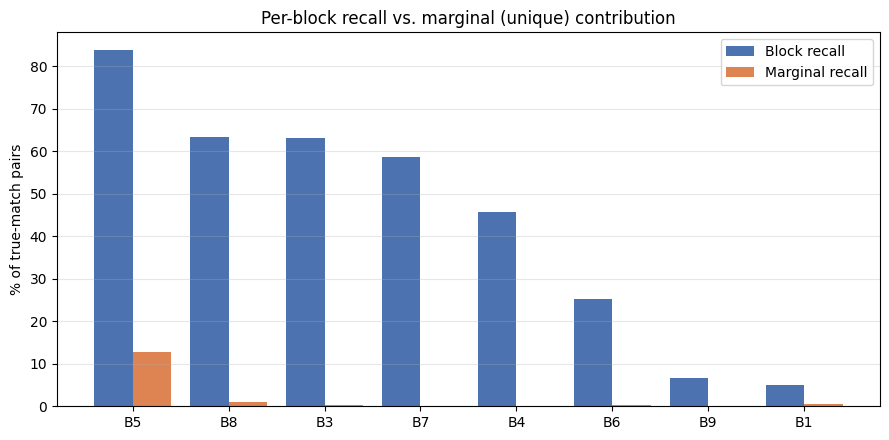

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(per_block))
ax.bar(x - 0.2, per_block["block_recall_%"], width=0.4, label="Block recall", color="#4C72B0")
ax.bar(x + 0.2, per_block["marginal_recall_%"], width=0.4, label="Marginal recall", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(per_block["block"])
ax.set_ylabel("% of true-match pairs")
ax.set_title("Per-block recall vs. marginal (unique) contribution")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Recall by corruption scenario (`case_type`)

Each true-match pair carries a `case_type` describing how the second record was corrupted (name typos, DOB shifts, SSN edits, phone changes, etc.). Breaking recall down by scenario shows **which kinds of real-world data variation the blocking scheme cannot bridge** — the actionable output for improving the blocks.

In [10]:
pos = truth_pos.copy()
pos["found"] = pos["pair"].isin(candidate_set)

by_case = (
    pos.groupby("case_type")
       .agg(n_pairs=("found", "size"), n_found=("found", "sum"))
       .assign(recall_pct=lambda d: (100 * d["n_found"] / d["n_pairs"]).round(1))
       .sort_values(["recall_pct", "n_pairs"], ascending=[True, False])
)

print("Worst-handled scenarios (lowest recall first):")
by_case.head(20)

Worst-handled scenarios (lowest recall first):


,n_pairs,n_found,recall_pct
case_type,,,
M-NOSSN-04,44,27,61.4
M-MIX-02,43,29,67.4
M-PHONE-02,43,39,90.7
M-PHONE-01,43,40,93.0
M-NAME-08,44,41,93.2
M-NAME-08b,43,41,95.3
M-NAME-03,44,42,95.5
M-NAME-04,44,42,95.5
M-L4-02,75,73,97.3


In [11]:
# Roll up by scenario family (the prefix before the first '-' detail), e.g.
# NM-HARD-DOB -> NM-HARD, M-SSN-05 -> M-SSN. Gives a higher-level view.
def _family(ct):
    parts = ct.split("-")
    return "-".join(parts[:2]) if len(parts) >= 2 else ct

pos["family"] = pos["case_type"].map(_family)
by_family = (
    pos.groupby("family")
       .agg(n_pairs=("found", "size"), n_found=("found", "sum"))
       .assign(recall_pct=lambda d: (100 * d["n_found"] / d["n_pairs"]).round(1))
       .sort_values("recall_pct")
)
by_family

,n_pairs,n_found,recall_pct
family,,,
M-MIX,86,72,83.7
M-NOSSN,176,158,89.8
M-PHONE,86,79,91.9
M-ZIP,43,42,97.7
M-L4,225,221,98.2
M-NAME,739,728,98.5
M-SSN,143,141,98.6
M-ADDR,258,257,99.6
M-DOB,32,32,100.0


## 7. False-negative inspection

The missed true-match pairs are the highest-value debugging artifact: each one is a pair of records that *should* have blocked together but didn't. We attach the original field values from both records so you can see exactly which fields diverged.

In [15]:
missed_df = truth_pos[truth_pos["pair"].isin(missed_pos)].copy()

pool_idx = df_pool.set_index("PATID")
INSPECT_COLS = [
    "FirstNM_clean", "LastNM_clean", "BirthDT_clean", "SSN_clean",
    "last_4_SSN", "ZipCD_clean_base", "Email_clean", "Phones_set",
]

def _side(patid, suffix):
    if patid not in pool_idx.index:
        return {f"{c}{suffix}": "<not in pool>" for c in INSPECT_COLS}
    r = pool_idx.loc[patid]
    return {f"{c}{suffix}": r[c] for c in INSPECT_COLS}

inspect_rows = []
for _, row in missed_df.iterrows():
    a, b = row["pair"]
    rec = {"PATID_A": a, "PATID_B": b, "case_type": row["case_type"]}
    rec.update(_side(a, "_A"))
    rec.update(_side(b, "_B"))
    inspect_rows.append(rec)

missed_inspect = pd.DataFrame(inspect_rows)
print(f"{len(missed_inspect):,} missed true-match pairs.")
missed_inspect.tail(25)

58 missed true-match pairs.


,PATID_A,PATID_B,case_type,FirstNM_clean_A,LastNM_clean_A,BirthDT_clean_A,SSN_clean_A,last_4_SSN_A,ZipCD_clean_base_A,Email_clean_A,Phones_set_A,FirstNM_clean_B,LastNM_clean_B,BirthDT_clean_B,SSN_clean_B,last_4_SSN_B,ZipCD_clean_base_B,Email_clean_B,Phones_set_B
33,S000080807,S000080808,M-NOSSN-04,ARMANDO,SMITH,1990-12-22,NaN,NaN,NaN,NaN,NaN,ARMANDO,YMITH,1990-12-22,NaN,NaN,NaN,NaN,NaN
34,S000083849,S000083850,M-NAME-08b,ROSA,JOHNSON,1999-07-22,NaN,1742,NaN,NaN,NaN,ROSA,JOHSON,1999-07-22,NaN,NaN,NaN,NaN,NaN
35,S000081951,S000081952,M-MIX-02,BRIAN,DAVIS,1974-04-23,NaN,NaN,96767,NaN,8086350453 8089593296,BRIAN,KDAVIS,1974-04-23,NaN,NaN,96767,NaN,8082579036 8089492781
36,S000081447,S000081448,M-MIX-02,LAURA,MENDOZA,2001-08-18,NaN,2208,60077,NaN,3318760008 7084919623 8159455221,LAURA,ENDOZA,2001-08-18,NaN,NaN,60659,NaN,6309931635 7087468634 8159471581
37,S000083615,S000083616,M-NOSSN-04,MARIA,WILLIAMS,1989-07-27,NaN,NaN,NaN,NaN,NaN,MARIA,WILLIAM,1989-07-27,NaN,NaN,NaN,NaN,NaN
38,S000083111,S000083112,M-NOSSN-04,JOSHUA,JONES,1999-10-18,NaN,NaN,NaN,NaN,NaN,JOSHUA,OJNES,1999-10-18,NaN,NaN,NaN,NaN,NaN
39,S000082317,S000082318,M-NOSSN-05,ERIC,MARTINEZ,1970-06-14,NaN,NaN,60632,NaN,NaN,ERIC,MARTITEZ,1970-06-14,NaN,NaN,60632,NaN,NaN
40,S000082311,S000082312,M-MIX-02,JOSHUA,JONES,2004-06-11,NaN,NaN,60624,NaN,3127476948 6303071264,JOSHUA,JONET,2004-06-11,NaN,NaN,60624,NaN,8156080511 8475043135
41,S000083103,S000083104,M-MIX-02,DIANA,KAHELE,1984-09-20,NaN,NaN,60632,NaN,3319827825 8473217930,DIANA,KAHESLE,1984-09-20,NaN,5842,60632,NaN,8152619252 8153861655
42,S000080657,S000080658,M-L4-02,MARIA,ROBINSON,2009-11-27,NaN,4244,60622,NaN,NaN,MARIA,ROBITNSON,2009-11-27,NaN,4244,60622,NaN,NaN


In [13]:
# Optional: persist the false negatives for offline review.
# (No PHI concern — this is synthetic data.)
OUT_PATH = SYNTH_DIR / "blocking_false_negatives.csv"
missed_inspect.to_csv(OUT_PATH, index=False)
print(f"Wrote {len(missed_inspect):,} missed pairs -> {OUT_PATH}")

Wrote 58 missed pairs -> /Users/miguelroca/Documents/UChicago/Capstone Project/EMPI/data/synthetic/blocking_false_negatives.csv


## 8. Summary scorecard

In [14]:
stats = get_blocking_stats(candidate_pairs.drop(columns=["pair"]))

summary = pd.Series({
    "records (N)":                 N,
    "candidate pairs":             len(candidate_set),
    "reduction ratio %":           round(reduction_ratio * 100, 4),
    "true-match pairs":            len(truth_pos_set),
    "recovered":                   len(found_pos),
    "missed (false neg)":          len(missed_pos),
    "PAIR COMPLETENESS (recall) %": round(recall * 100, 2),
    "hard-neg pairs":              len(truth_neg_set),
    "hard-neg captured %":         round(neg_capture * 100, 1),
    "cross-block overlap %":       stats.get("overlap_pct"),
})
summary.to_frame("value")

,value
records (N),20000.0000
candidate pairs,7191.0000
reduction ratio %,99.9964
true-match pairs,2000.0000
recovered,1942.0000
missed (false neg),58.0000
PAIR COMPLETENESS (recall) %,97.1000
hard-neg pairs,8000.0000
hard-neg captured %,14.0000
cross-block overlap %,47.9000
